# **It's All Greek To Me!**
The topic of this project is **Language Indentification**, the task of determining the language a piece of text or speech is written or spoken in.
For simplicity I will only focus on *written* language.

In this notebook I am going to implement from scratch my version of the algorithm used to solve the problem, provide a toy example on a small scale to explain how the model works in practice and then apply it to a real-world situation, evaluating its performance.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import *
from scipy.sparse import csr_matrix, find
import string
from os import remove
import warnings as wrn

# Implementing the Algorithm
In this section I define the class *myMNB*, which is going to be employed for the fitting of the model and the prediction of new documents.

In [30]:
class myMNB:
    # CONSTRUCTOR
    def __init__(self, languages=None):
        self.classes = languages
        self.priors = {}
        self.log_densities = {}
        self.size_voc = 0

    # GETTERS
    def get_classes(self):
        return self.classes

    def get_priors(self, label):
        return self.priors[label]

    def get_log_densities(self, label):
        return self.log_densities[label]

    # SETTERS
    def set_classes(self, classes):
        self.classes = classes

    def set_priors(self, label, value):
        self.priors[label] = value

    def set_log_densities(self, label, densities):
        self.log_densities[label] = densities

    # METHODS

    def fit(self, x_train, y_train):
        # x_train is the sparsified data
        n_samples, self.size_voc = x_train.shape
        if self.get_classes() == None:
            self.set_classes( np.unique(y_train) ) # setting the classes
        y_train = np.array(y_train)
        for index_l, label in enumerate(self.get_classes()):
            x_train_l = x_train[ y_train == label ]  # gets the training set having label l
            pi_hat = x_train_l.shape[0] / n_samples
            self.set_priors(str(label), pi_hat)
            n_l_j = np.zeros(self.size_voc, dtype=np.float64 )
            W_l = 0
            for word_i in range(self.size_voc):
                n_l_j[word_i] = np.sum(x_train_l[:, word_i])
                    # sum of the occurrences of the j-th word in x_train_l
                W_l += n_l_j[word_i]
                    # progressively computes the total number of words occurrences in the l-th class
            log_f_hat_l_i = np.log(n_l_j + 1) - np.log(W_l + self.size_voc)
                # array-wise smoothed estimated of the conditional densities
            self.set_log_densities(label, log_f_hat_l_i)

    def calc_posteriors(self, x_new):
        # computation of the posterior probabilities
        if len(self.get_classes()) == 0:
            raise ValueError('The model has not been fitted yet!')
        x_de_sparse = find(x_new) # to access the elements stored in the sparse matrix
        x_attr = x_de_sparse[1] # gets the indexes of the words of x_new in the vocabulary
        x_new = x_de_sparse[2] # gets the occurrences of words in x_new
        log_posterior = np.zeros(len(self.get_classes()), dtype=np.float64)
        for index_l, label in enumerate(self.get_classes()):
            log_posterior[index_l] = np.log(self.get_priors(label))
                # retrieves the prior
            for ind_x, word in enumerate(x_attr):
                log_posterior[index_l] += x_new[ind_x] * self.get_log_densities(label)[word]
                    # the unnormalized log-posterior is progressively computed
        marginal = np.sum(np.exp(log_posterior))
            # computing the marginal density of x_new
        if marginal != 0:
            log_posterior = log_posterior - np.log(marginal)
                # array-wise computing the proper posterior probabilities
        return log_posterior

    def predict_one(self, x_new):
        # to predict the language of a single new sentence
        if x_new.shape[0] > 1:
            raise ValueError('Too many new observations to predict!')
        post = self.calc_posteriors(x_new) # posteriors calculation
        y_pred = str(self.get_classes()[np.argmax(post)])
        p_hat = float( np.round(np.exp(np.max(post)), 5) )
        return y_pred, p_hat

    def predict_batch(self, xx_new):
        # to predict the language of more than one sentence
        if xx_new.shape[0] == 1:
            wrn.warn("For predicting one new observation it is recommended to use predict_one()")
        y_pred = [0 for i in range(xx_new.shape[0])]
            # creating a list to accommodate the predictions
        for index, x in enumerate(xx_new):
            pred_x = self.predict_one(x)[0]
            y_pred[index] = pred_x
        return y_pred

    def predict_posteriors(self, x_new):
        # to explicitly compute and display the posterior probabilities
        P = {}
        post = self.calc_posteriors(x_new)
        y_pred = str( self.get_classes()[np.argmax(post)] )
        for index, label in enumerate(self.get_classes()):
            P[str(label)] = float( np.round(np.exp(post[index]), 5) )
        return y_pred, P

# Toy Example


The training set considered for this toy example is:

| Text| Language |
|-------------------|:------------------:|
   | Het-weer-is-mooi-vandaag! | Dutch |
   | Ben ik een1 goed persoo00n? | Dutch |
   | The Weather is nice Today... | English |
   | You Are Good" | English |
   | Oggi fa freddo1! | Italian |
   | SeI Un Br34AvO UoMo" | Italian |

The test set is:

| Text| Language |
|-------------------|:------------------:|
   | Vandaag ben ik heel Goed goed | Dutch |
   | I AM GOOD AND NICE WITH YOU!? | English |
   | sono un UOMO freddo | Italian |

In [31]:
toy_labels = ['Dutch','English', 'Italian']

x_train_toy = [
    "Het-weer-is-mooi-vandaag!",
    "Ben ik een1 goed persoo00n?",
    "The Weather is nice Today...",
    "You Are Good",
    "Oggi fa freddo1!",
    "SeI Un Br34AvO UoMo"
]
y_train_toy = ["Dutch","Dutch","English","English","Italian","Italian"]

data_train_toy = pd.DataFrame({'Text':x_train_toy, 'Language': y_train_toy})

x_test_toy = [
    "Vandaag ben ik heel Goed goed",
    "I AM GOOD AND NICE WITH YOU!?",
    "sono un UOMO freddo",
]
y_test_toy = ["Dutch", "English", "Italian"]

In [32]:
data_train_toy

,Text,Language
0,Het-weer-is-mooi-vandaag!,Dutch
1,Ben ik een1 goed persoo00n?,Dutch
2,The Weather is nice Today...,English
3,You Are Good,English
4,Oggi fa freddo1!,Italian
5,SeI Un Br34AvO UoMo,Italian


## Preprocessing
In this phase I am going to prepare data for the application of the algorithm.
This includes cleaning up the documents and transforming them into the sparse matrices.

Since text data are a bit noisy, meaning that words may contain both upper and lower case letters, numbers and punctuation marks, I need to refine the documents, I begin with addressing this issue. \
To do so I use the function `text_preprocess()`, taking care of removing digits, punctuation and other special characters and also converting all letters to lower case.
It exploits the variables `digits` and `punctuation` from the library `string`.


In [33]:
def text_preprocess(corpus):

    remove_table = str.maketrans('', '', string.punctuation + string.digits)
        # define a translation table to remove punctuation and digits
    cleaned = []
    for doc in corpus:
        # iterate over each sentence in the list and clean it
        doc = doc.lower() # lower-case
        doc = doc.replace('-', ' ')
        doc = doc.replace('–', ' ')
        doc = doc.translate(remove_table)
        cleaned.append(doc)

    return cleaned

Notice that I need to replace the dash separating two words with a whitespace, for them to be correctly split in the following step.

In [34]:
x_train_toy = text_preprocess(x_train_toy)
x_test_toy = text_preprocess(x_test_toy)

In [35]:
print(x_train_toy)
print(x_test_toy)

['het weer is mooi vandaag', 'ben ik een goed persoon', 'the weather is nice today', 'you are good', 'oggi fa freddo', 'sei un bravo uomo']
['vandaag ben ik heel goed goed', 'i am good and nice with you', 'sono un uomo freddo']


Next is the transformation of plain text to the sparse matrices of occurrencies. I start with building both the vocabulary and the count matrix from the training set `x_train_toy` and then the latter procedure is performed also on the `x_test_toy`, using the vocabulary just built. \
The tokenization of the documents in the training set is carried out using the `split()` method, which breaks sentences into a list of words, using any whitespace as separator, while the unique words are stored in the Python set `vocabulary`, so that the presence of repeated words is ruled out.

In order to have more control on the outputs and deliver insights more easily, I wrote myself the functions `my_count_vect()` and `my_count_vect_new()` from scratch.

In [36]:
def my_count_vect(x_train):
    token_doc = [doc.split() for doc in x_train]
    # nested list with the tokenized words from every document, respectively

    vocabulary = set() # to store only unique values
    for doc in token_doc:
        for word in doc:
            if len(word) >= 2: # ignores the 1-letter words
                vocabulary.add(word)
    vocabulary = sorted(vocabulary)

    count_matrix = []
    for doc in token_doc:
        word_occ = [doc.count(word) for word in vocabulary]
            # counts the occurrences of the selected word in the selected document
        count_matrix.append(word_occ) # builds the count matrix
    return vocabulary, count_matrix


def my_count_vect_new(x_test, vocabulary):
    new_token_doc = [doc.split() for doc in x_test]
        # tokenize the new documents
    new_count_matrix = []
    for doc in new_token_doc:
        new_word_occ = [doc.count(word) for word in vocabulary]
            # create the count vector for each new document based on the training vocabulary
        new_count_matrix.append(new_word_occ)

    return new_count_matrix

Now I can actually compute and visualize the matrices $ C_\text{train} $ and $
C_\text{test} $.

In [37]:
vocabulary, x_train_toy = my_count_vect(x_train_toy)
print(vocabulary)
print(np.array(x_train_toy))
np.array(x_train_toy).shape

['are', 'ben', 'bravo', 'een', 'fa', 'freddo', 'goed', 'good', 'het', 'ik', 'is', 'mooi', 'nice', 'oggi', 'persoon', 'sei', 'the', 'today', 'un', 'uomo', 'vandaag', 'weather', 'weer', 'you']
[[0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0]
 [0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0]]


(6, 24)

In [38]:
x_test_toy = my_count_vect_new(x_test_toy, vocabulary)
print(np.array(x_test_toy))
np.array(x_test_toy).shape

[[0 1 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0]]


(3, 24)

Despite having just six documents overall, the vocabulary already contains 24 unique words, resulting in a pretty large count matrices.

To store only the non-zero values I need to sparsify the matrices, using the `scipy.sparse` module:

In [39]:
x_train_toy = csr_matrix(x_train_toy)
x_test_toy = csr_matrix(x_test_toy)

## Fitting and Predictions
Now I can finally fit the algorithm and get some predictions for the test set at hand.

In [40]:
nb_toy = myMNB()
nb_toy.fit(x_train_toy, y_train_toy)

Let's look up some of the quantities just computed:

In [41]:
nb_toy.priors

{'Dutch': 0.3333333333333333,
 'English': 0.3333333333333333,
 'Italian': 0.3333333333333333}

In [42]:
np.exp(nb_toy.get_log_densities('English'))

array([0.0625 , 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125,
       0.0625 , 0.03125, 0.03125, 0.0625 , 0.03125, 0.0625 , 0.03125,
       0.03125, 0.03125, 0.0625 , 0.0625 , 0.03125, 0.03125, 0.03125,
       0.0625 , 0.03125, 0.0625 ])

In [43]:
y_toy_pred = nb_toy.predict_batch(x_test_toy)
print(y_toy_pred)

['Dutch', 'English', 'Italian']


I can also display the estimated posterior probabilities for each of the document in $D_\text{test}$, alongside the predicted language.

In [44]:
nb_toy.predict_posteriors(x_test_toy[0])

('Dutch', {'Dutch': 0.91583, 'English': 0.03875, 'Italian': 0.04542})

In [45]:
nb_toy.predict_posteriors(x_test_toy[1])

('English', {'Dutch': 0.08393, 'English': 0.80534, 'Italian': 0.11073})

In [46]:
nb_toy.predict_posteriors(x_test_toy[2])

('Italian', {'Dutch': 0.07841, 'English': 0.09405, 'Italian': 0.82755})

Now I evaluate the performance of the algorithm, using the accuracy metric and displaying the confusion matrix.

Accuracy Score: 1.0


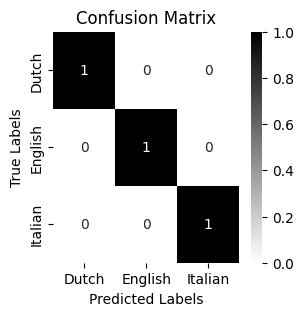

In [47]:
print('Accuracy Score:', accuracy_score(y_test_toy, y_toy_pred))
conf_m = confusion_matrix(y_test_toy, y_toy_pred, labels = toy_labels)
plt.figure(figsize=(3, 3))  # Adjust size to accommodate 8x8 matrix
sbn.heatmap(conf_m, annot=True, fmt="d",
            xticklabels=toy_labels, yticklabels=toy_labels, cmap = plt.cm.gray_r)
            # cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

As a result, the predictions are correct for all the three documents and therefore the accuracy over the test set is equal to 1.  
Of course this is due to the small size of the dataset considered in this toy example, whose only goal is explaining how the algorithm actually works in practice.

# Simulations
In this chapter I am going to conduct a simulation in a plausible real-world situation, executing the algorithm on a bigger scale, evaluating its performance and then give a brief interpration of the results obtained. \
For these purposes I work with WiLI-2018, a dataset of short text extracts from Wikipedia specifically created for Language Identification tasks, containing 1000 paragraphs for each of the 235 different languages.
It is freely available at https://huggingface.co/datasets/MartinThoma/wili_2018 with the related documentation. \
I decided to consider only $L=10$ among the 235 languages provided by WiLI-2018, namely \
$ \mathcal{L} = \left\lbrace \text{Danish, Dutch, English, Finnish, French, German,  Italian, Portuguese, Spanish, Swedish} \right\rbrace $. \
Thus the dataset has $N=10,000$ samples from the selected languages.

In the next few code cells I download the dataset and do a little bit of polishing. \\
The dataset is originally composed of two separate parts and thus I need to merge them to obtain the full data. \\
I also keep only the ten languages I selected and have a look at how the dataset is organised.

In [48]:
splits = {'train': 'WiLI-2018 dataset/train-00000-of-00001.parquet', 'test': 'WiLI-2018 dataset/test-00000-of-00001.parquet'}
df1 = pd.read_parquet("hf://datasets/MartinThoma/wili_2018/" + splits["train"])
df2 = pd.read_parquet("hf://datasets/MartinThoma/wili_2018/" + splits["test"])

In [49]:
lng_labels = {
            31: 'German',
            39: 'Portuguese',
            41: 'English',
            62: 'Danish',
            82: 'French',
            86: 'Finnish',
            93: 'Swedish',
            126: 'Italian',
            185: 'Dutch',
            188: 'Spanish'
}
lng_labels = dict(sorted(lng_labels.items(), key=lambda item: item[1]))

y_labels = list(lng_labels.values())
# storing the list of languages chosen to be extracted from the full dataset

lng_keep = list(lng_labels.keys())
# list of the languages to keep

print(y_labels)

['Danish', 'Dutch', 'English', 'Finnish', 'French', 'German', 'Italian', 'Portuguese', 'Spanish', 'Swedish']


In [50]:
data = pd.concat([df2, df1], ignore_index=True)
data.rename(columns = {'label':'Language', 'sentence':'Text'}, inplace=True)
data = data.query('Language in @lng_keep').reset_index(drop=True)
# extracting the selected languages

data.replace(lng_labels, inplace=True)
print(data.shape)
data.head()

(10000, 2)


,Text,Language
0,Schiedam is gelegen tussen Rotterdam en Vlaard...,Dutch
1,Carol Oskar Eugen Lindroos (29. toukokuuta 193...,Finnish
2,La ciudad de San Cristóbal es sede del Hospita...,Spanish
3,Les supporters de l'ASM Clermont Auvergne ont ...,French
4,Anton (or Antonius) Maria Schyrleus (also Schy...,English


I also check with a bar plot that the dataset is balanced as it claims to be:

Text(0.5, 1.0, 'Languages Balance')

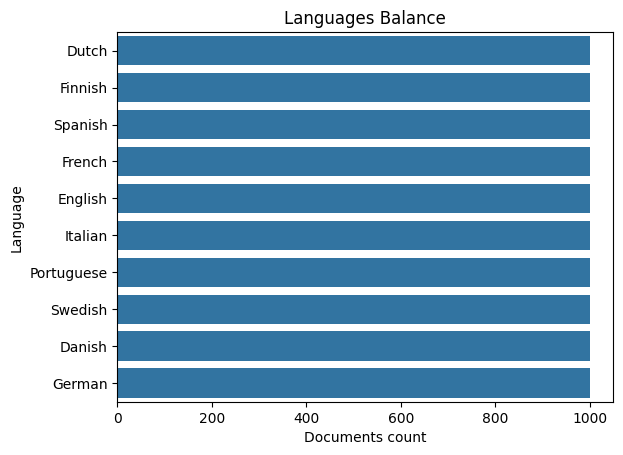

In [51]:
sbn.countplot(data['Language'])
plt.xlabel('Documents count')
plt.title('Languages Balance')

Since the number of documents is 1,000 for each language, the dataset is balanced.

## Preprocessing
Now the next step is splitting them in the training and test sets, with $D_\text{test}$ chosen to be the 30\% of $D$, resulting in $ n=|D_\text{train}|=7,000 $ and $ m = |D_\text{test}|=3,000 $, with $300$ documents per language. \
To ensure both sets are balanced, I applied a stratified approach to sample the same number of documents per language and then look for a visual confirmation.

In [65]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, shuffle=True,
                                                    stratify = y, random_state = 42)

print('Training set length:', len(y_train))
print('Test set length:', len(y_test))


Training set length: 7000
Test set length: 3000


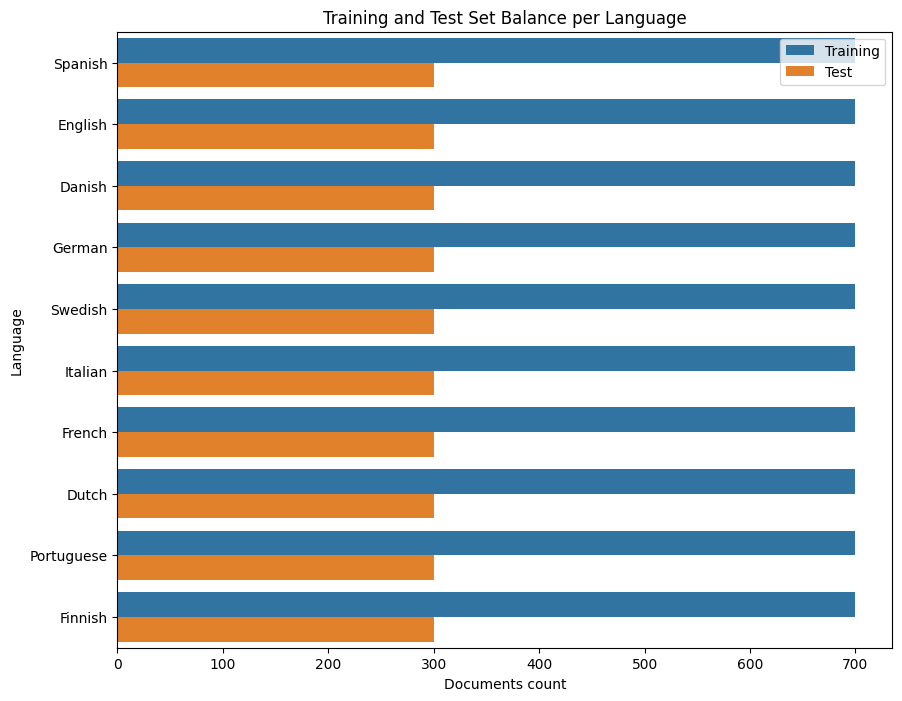

In [53]:
x = data['Text']
y = data['Language']

# Create a DataFrame for plotting grouped bars
train_counts = y_train.value_counts().reset_index()
train_counts['Set'] = 'Training'
test_counts = y_test.value_counts().reset_index()
test_counts['Set'] = 'Test'

plot_df = pd.concat([train_counts, test_counts])
plot_df.columns = ['Language', 'Count', 'Set']

plt.figure(figsize=(10, 8))
# Swapping x and y for horizontal orientation
sbn.barplot(data=plot_df, x='Count', y='Language', hue='Set')
plt.xlabel('Documents count')
plt.ylabel('Language')
plt.title('Training and Test Set Balance per Language')
plt.legend()
plt.show()

Now I can remove all the punctuation marks, symbols and numbers from the text with the `text_preprocess()` function and then build $C_\text{train}$ and $C_\text{test}$. \
This latter operation is done using the module `CountVectorizer()` from `scikit-learn`, since relying on functions built from scratch would require too much time.

In [66]:
x_train = text_preprocess(x_train)
x_test = text_preprocess(x_test)

# vect=CountVectorizer()
vect=CountVectorizer(min_df=3)
vect.fit(x_train)
x_train = vect.transform(x_train)
x_test = vect.transform(x_test)

print(x_train.shape)
print(x_test.shape)
x_train

(7000, 18340)
(3000, 18340)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 223679 stored elements and shape (7000, 18340)>

As a result, $C_\text{train}$ has dimensions $(7,000 \times 90,092)$, implying that the vocabulary contains 90,092 unique words. \
However, the stored values are just 308,453, implying that approximately 99.95 % of the matrix is made of null values.

Also, choosing to ignore the words appearing less than 3 times (`CountVectorizer(min_df=3)`) we obtain a smaller vocabulary with only $18,340$ words resulting in a significantly quicker fit process, while the accuracy rate does not change.

## Fitting and Prediction
Having done all the preparations required, I am now ready to apply the algorithm. \
I start with fitting the model on $D_\text{train}$, and the look up some of the calculated quantities.

In [67]:
nb = myMNB()
nb.fit(x_train, y_train)

In [68]:
nb.get_classes()

array(['Danish', 'Dutch', 'English', 'Finnish', 'French', 'German',
       'Italian', 'Portuguese', 'Spanish', 'Swedish'], dtype=object)

In [69]:
print(nb.priors)

{'Danish': 0.1, 'Dutch': 0.1, 'English': 0.1, 'Finnish': 0.1, 'French': 0.1, 'German': 0.1, 'Italian': 0.1, 'Portuguese': 0.1, 'Spanish': 0.1, 'Swedish': 0.1}


In [70]:
print(nb.get_log_densities('Finnish'))

[-10.48949486 -10.48949486 -10.48949486 ... -10.48949486 -10.48949486
 -10.48949486]


To get the predictions for the testing corpus, it's enough to apply the method `predict_batch()`.

In [71]:
lang_pred = nb.predict_batch(x_test)
print(lang_pred)

['Dutch', 'English', 'Finnish', 'French', 'Danish', 'French', 'German', 'Dutch', 'Dutch', 'German', 'Swedish', 'English', 'Finnish', 'Finnish', 'Portuguese', 'Dutch', 'Finnish', 'French', 'Italian', 'Swedish', 'Dutch', 'French', 'Swedish', 'Italian', 'Dutch', 'Spanish', 'Swedish', 'Danish', 'German', 'English', 'Italian', 'French', 'Spanish', 'Danish', 'Spanish', 'Dutch', 'Danish', 'French', 'German', 'Italian', 'English', 'Italian', 'Finnish', 'Italian', 'Danish', 'French', 'Italian', 'Portuguese', 'Spanish', 'Spanish', 'Portuguese', 'Finnish', 'Danish', 'Swedish', 'Italian', 'Dutch', 'English', 'French', 'French', 'Danish', 'Spanish', 'English', 'Danish', 'Spanish', 'Dutch', 'Italian', 'German', 'French', 'Swedish', 'Swedish', 'Danish', 'Danish', 'Finnish', 'French', 'Italian', 'German', 'French', 'French', 'Finnish', 'Italian', 'Danish', 'Dutch', 'Portuguese', 'Spanish', 'Swedish', 'Portuguese', 'Portuguese', 'Portuguese', 'Finnish', 'German', 'German', 'Spanish', 'Swedish', 'German

Next is the performance evaluation, using the accuracy score and the confusion matrix.

Accuracy Score: 0.981


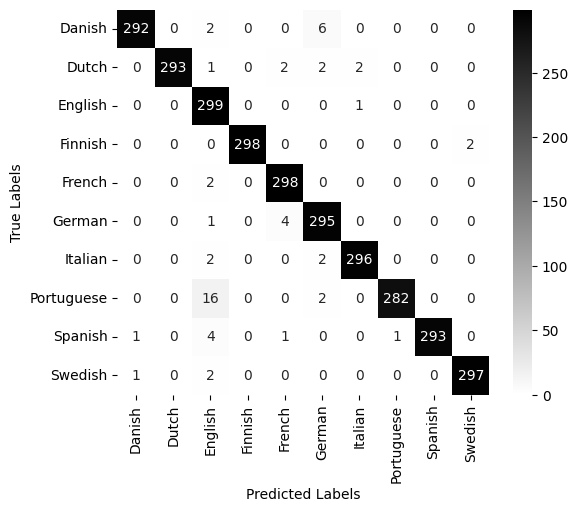

In [72]:
print('Accuracy Score:', accuracy_score(y_test, lang_pred))
conf_matr = confusion_matrix(y_test, lang_pred, labels = y_labels)
plt.figure(figsize=(6, 5))
sbn.heatmap(conf_matr, annot=True, fmt="d",
            xticklabels=y_labels, yticklabels=y_labels, cmap = plt.cm.gray_r)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

The figures on the main diagonal of the confusion matrix are almost all close to the maximum achievable of 300, meaning that most of the documents in the test set are correctly classified. \
The model appears to separate well the languages, as it does an excellent job even with languages which are known to be similar to each other, like Danish, Finnish and Swedish or Portuguese and Spanish, committing only a handful of misclassifications in these classes. \
On the not-so-bright side, there some mistakes concentration: they occur mainly when predicting as English.
This is especially true for Portuguese, with 16 documents incorrectly assigned to English: this figure stands out in the *predicted-as-English* column and should be object of further and deeper analysis. \
With these considerations and an accuracy score of 0.981 I can call myself remarkably satisfied with the results obtained in this project.